<a href="https://colab.research.google.com/github/47294/game_theory_course_spring2026/blob/main/network_attack/network_traffic_classfication_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Классификация сетевого трафика и обнаружение атак с помощью нейронных сетей (PyTorch)

---

В этом ноутбуке мы пройдём полный путь от **анализа сетевого трафика** до **построения нейросетевого классификатора** для обнаружения сетевых атак.

### Содержание

1. **Сетевые потоки (Network Flows)** — что это такое, какие признаки извлекаются из трафика, пример с NFStream
2. **Введение в PyTorch** — тензоры, операции, автоматическое дифференцирование
3. **Предобработка данных** — загрузка, нормализация, разделение выборки
4. **Нейронная сеть в PyTorch** — архитектура, инициализация весов
5. **Обучение модели** — пакетный градиентный спуск, метрики, мониторинг
6. **Оптимизатор Adam** — адаптивная скорость обучения
7. **Борьба с переобучением** — регуляризация, Dropout, ранняя остановка

> 📌 Ноутбук рассчитан на запуск в **Google Colab**. Все зависимости устанавливаются прямо в ячейках.

![netflow](https://www.ringcentral.com/gb/en/blog/wp-content/uploads/2021/08/network-header-components.png)
---
## 1. Сетевые потоки (Network Flows) и признаки потоков

### 1.1 Что такое сетевой поток?

**Сетевой поток (Network Flow)** — это последовательность пакетов между двумя конечными точками (IP-адрес + порт), объединённых по общим признакам:

- **Source IP / Destination IP** — адреса отправителя и получателя
- **Source Port / Destination Port** — порты отправителя и получателя
- **Protocol** — транспортный протокол (TCP, UDP, ICMP)

Такая группировка позволяет из миллионов отдельных пакетов получить компактное описание сетевых сессий.

### 1.2 Признаки потоков (Flow Features)

Из каждого потока извлекаются статистические характеристики, например:

| Категория | Примеры признаков |
|-----------|-------------------|
| **Объёмные** | Общее число пакетов, суммарный размер, байты/сек |
| **Временные** | Длительность потока, среднее/макс/мин межпакетное время (IAT) |
| **Пакетные** | Средний/макс/мин размер пакета, стандартное отклонение |
| **Направленные** | Отдельно для прямого (Fwd) и обратного (Bwd) направлений |
| **Заголовочные** | Размер заголовков, флаги TCP |

Именно эти признаки становятся входными данными для моделей машинного обучения.

### 1.3 NFStream — библиотека для извлечения признаков

[NFStream](https://www.nfstream.org/) — это мощная Python-библиотека для анализа сетевого трафика. Она умеет читать **pcap-файлы** (формат записи сетевого трафика) и автоматически:
- агрегировать пакеты в потоки
- вычислять десятки статистических признаков
- экспортировать результат в Pandas DataFrame

In [45]:
# Установка NFStream
# NFStream требует libpcap, который уже установлен в Colab
!pip install nfstream -q

In [46]:
# Скачиваем демонстрационный pcap-файл
# Используем публичный pcap из репозитория Wireshark
!wget -q https://github.com/nfstream/nfstream/raw/master/tests/pcaps/facebook.pcap -O demo_traffic.pcap
print("✅ Файл demo_traffic.pcap загружен")

✅ Файл demo_traffic.pcap загружен


In [47]:
from nfstream import NFStreamer

# Создаём стример для обработки pcap-файла
# statistical_analysis=True включает вычисление расширенных статистических признаков
streamer = NFStreamer(
    source="demo_traffic.pcap",
    statistical_analysis=True  # включаем расчёт статистик по пакетам
)

# Преобразуем результат в DataFrame
flows_df = streamer.to_pandas()

print(f"Количество обнаруженных потоков: {len(flows_df)}")
print(f"\nКоличество признаков: {len(flows_df.columns)}")
print(f"\nПримеры признаков:")
print(flows_df.columns.tolist()[:20])

Количество обнаруженных потоков: 2

Количество признаков: 86

Примеры признаков:
['id', 'expiration_id', 'src_ip', 'src_mac', 'src_oui', 'src_port', 'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol', 'ip_version', 'vlan_id', 'tunnel_id', 'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms', 'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_first_seen_ms']


In [48]:
# Посмотрим на первые несколько потоков
# Выберем наиболее интересные столбцы для демонстрации
key_columns = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol',
    'bidirectional_packets', 'bidirectional_bytes',
    'bidirectional_duration_ms',
    'src2dst_packets', 'dst2src_packets',
    'bidirectional_mean_ps',   # средний размер пакета
    'bidirectional_max_ps',    # максимальный размер пакета
]

# Показываем только те столбцы, которые есть в данных
available_cols = [c for c in key_columns if c in flows_df.columns]
flows_df[available_cols].head(10)

,src_ip,dst_ip,src_port,dst_port,protocol,bidirectional_packets,bidirectional_bytes,bidirectional_duration_ms,src2dst_packets,dst2src_packets,bidirectional_mean_ps,bidirectional_max_ps
0,192.168.43.18,66.220.156.68,52066,443,6,19,5745,1300,9,10,302.368421,1454
1,192.168.43.18,31.13.86.36,44614,443,6,41,24766,679,19,22,604.048780,1454


### 1.4 Как это используется в обнаружении атак?

В реальных системах обнаружения вторжений (IDS — Intrusion Detection System) процесс выглядит так:

```
Сетевой трафик (pcap)  →  NFStream  →  Flow Features  →  ML-модель  →  Normal / Attack
```

Популярные датасеты для обучения:
- **CICIDS2017/2018** — от Канадского института кибербезопасности
- **NSL-KDD** — улучшенная версия классического KDD Cup 99
- **UNSW-NB15** — от Австралийского центра кибербезопасности

Далее в ноутбуке мы будем работать с данными, имеющими структуру, аналогичную **CICIDS** — набором признаков потоков с бинарной меткой (0 — нормальный трафик, 1 — атака).

---
## 2. Введение в PyTorch и тензоры

### 2.1 Что такое PyTorch?

**PyTorch** — это фреймворк для глубокого обучения, разработанный в Meta AI (бывш. Facebook). Его ключевые особенности:

- 🔥 **Динамический вычислительный граф** — граф строится «на лету» при каждом проходе, что упрощает отладку
- 📐 **Тензоры** — многомерные массивы с поддержкой GPU-ускорения
- ⚡ **Автоградиент (Autograd)** — автоматическое вычисление производных
- 🧩 **Модульная архитектура** — удобные абстракции для построения нейросетей

### 2.2 Тензоры — основа PyTorch

**Тензор** — это обобщение понятий скаляра, вектора и матрицы:

| Размерность | Математическое название | Пример |
|-------------|------------------------|--------|
| 0D | Скаляр | Температура: 36.6 |
| 1D | Вектор | Признаки одного потока: [128, 0.5, ...] |
| 2D | Матрица | Батч потоков: [[...], [...], ...] |
| 3D+ | Тензор | Изображения, видео, временные ряды |

In [49]:
import torch
import numpy as np

# PyTorch уже установлен в Google Colab
print(f"Версия PyTorch: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

# Устройство для вычислений — GPU если доступен, иначе CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Версия PyTorch: 2.10.0+cpu
CUDA доступна: False
Используемое устройство: cpu


In [50]:
# === Создание тензоров ===

# Из списка Python
t1 = torch.tensor([1.0, 2.0, 3.0])
print(f"Из списка:        {t1}, shape={t1.shape}, dtype={t1.dtype}")

# Из NumPy массива (данные разделяются в памяти!)
np_array = np.array([[1, 2], [3, 4]], dtype=np.float32)
t2 = torch.from_numpy(np_array)
print(f"Из NumPy:         {t2.shape}")

# Специальные тензоры
t_zeros = torch.zeros(3, 4)         # матрица 3x4 из нулей
t_ones  = torch.ones(2, 3)          # матрица 2x3 из единиц
t_rand  = torch.randn(2, 3)         # случайные числа из N(0,1)
t_eye   = torch.eye(3)              # единичная матрица 3x3

print(f"\nНули (3x4):       {t_zeros.shape}")
print(f"Случайные (2x3):\n{t_rand}")

Из списка:        tensor([1., 2., 3.]), shape=torch.Size([3]), dtype=torch.float32
Из NumPy:         torch.Size([2, 2])

Нули (3x4):       torch.Size([3, 4])
Случайные (2x3):
tensor([[-1.5402, -1.4824, -0.3896],
        [ 0.6448,  0.4454,  0.4149]])


In [51]:
# === Операции с тензорами ===

a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

# Поэлементные операции
print("Сложение:\n", a + b)
print("Умножение (поэлементное):\n", a * b)

# Матричное умножение — ключевая операция в нейросетях
print("Матричное умножение:\n", a @ b)  # эквивалент torch.matmul(a, b)

# Агрегации
print(f"\nСумма всех элементов a: {a.sum()}")
print(f"Среднее по столбцам a:  {a.mean(dim=0)}")
print(f"Максимум по строкам a:  {a.max(dim=1).values}")

Сложение:
 tensor([[ 6.,  8.],
        [10., 12.]])
Умножение (поэлементное):
 tensor([[ 5., 12.],
        [21., 32.]])
Матричное умножение:
 tensor([[19., 22.],
        [43., 50.]])

Сумма всех элементов a: 10.0
Среднее по столбцам a:  tensor([2., 3.])
Максимум по строкам a:  tensor([2., 4.])


In [52]:
# === Автоградиент (Autograd) — основа обучения нейросетей ===

# requires_grad=True говорит PyTorch отслеживать все операции с этим тензором
x = torch.tensor([2.0, 3.0], requires_grad=True)

# Прямой проход: вычисляем функцию y = x₁² + 2*x₂²
y = x[0]**2 + 2 * x[1]**2
print(f"y = {y.item():.1f}")  # 2² + 2*3² = 4 + 18 = 22

# Обратный проход: вычисляем градиенты dy/dx
y.backward()

# Градиенты: dy/dx₁ = 2*x₁ = 4, dy/dx₂ = 4*x₂ = 12
print(f"Градиенты: {x.grad}")  # tensor([4., 12.])

# Именно так PyTorch вычисляет градиенты функции потерь
# по параметрам нейросети — автоматически!

y = 22.0
Градиенты: tensor([ 4., 12.])


> 💡 **Ключевая идея**: PyTorch строит **вычислительный граф** всех операций. При вызове `.backward()` он проходит граф в обратном порядке и вычисляет градиенты с помощью **цепного правила (chain rule)**. Это позволяет обучать нейросети с миллионами параметров.

---
## 3. Предобработка данных

### 3.1 Загрузка и исследование данных

Для обучения нашего классификатора мы будем использовать датасет с признаками сетевых потоков, аналогичный тем, что извлекает NFStream или CICFlowMeter.

**Структура данных:**
- **37 числовых признаков** — статистики пакетов, временные характеристики, заголовки
- **1 бинарная метка (Label)** — 0 (нормальный трафик), 1 (атака)
- **8674 записи** — 5708 нормальных и 2966 атак

Это типичный пример **несбалансированного** датасета (соотношение ~2:1).

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Генерируем синтетические данные, имитирующие реальный датасет CICIDS
# В реальном проекте здесь будет pd.read_csv("your_dataset.csv")

np.random.seed(42)

!wget https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/network_attack/data.csv
df = pd.read_csv('data.csv')

# Названия признаков — типичные для CICFlowMeter / CICIDS
feature_names = [
    'Min Packet Length', 'Flow Packets/s', 'Average Packet Size',
    'Max Packet Length', 'Bwd Packet Length Std', 'Flow Bytes/s',
    'Packet Length Std', 'Fwd Packet Length Mean', 'Flow Duration',
    'Fwd Packet Length Min', 'Flow IAT Mean', 'Fwd IAT Min',
    'Total Fwd Packets', 'Fwd IAT Mean', 'Total Length of Fwd Packets',
    'Fwd IAT Std', 'Bwd IAT Mean', 'Flow IAT Max', 'Bwd Packets/s',
    'Flow IAT Std', 'Fwd Header Length', 'Label', 'Bwd Packet Length Min',
    'Bwd Packet Length Mean', 'Fwd Packet Length Max', 'Bwd IAT Max',
    'Fwd IAT Total', 'Fwd Packet Length Std', 'Bwd IAT Std',
    'Bwd Header Length', 'Fwd IAT Max', 'Bwd Packet Length Max',
    'Bwd IAT Min', 'Fwd Packets/s', 'Bwd IAT Total',
    'Packet Length Variance', 'Total Length of Bwd Packets', 'Flow IAT Min',
    'Packet Length Mean'
]

# Убираем 'Label' из списка признаков — это целевая переменная
feature_cols = [f for f in feature_names if f != 'Label']


# df['Label'] = all_labels.astype(int)

# Перемешиваем строки
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Размер датасета: {df.shape}")
print(f"\nРаспределение классов:")
print(df['Label'].value_counts())

--2026-04-15 21:01:30--  https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/network_attack/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2151666 (2.1M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   2.05M  --.-KB/s    in 0.06s   

2026-04-15 21:01:31 (35.8 MB/s) - ‘data.csv.1’ saved [2151666/2151666]

Размер датасета: (8674, 39)

Распределение классов:
Label
0    5708
1    2966
Name: count, dtype: int64


In [54]:
# Посмотрим на первые записи
df.head()

,Min Packet Length,Flow Packets/s,Average Packet Size,Max Packet Length,Bwd Packet Length Std,Flow Bytes/s,Packet Length Std,Fwd Packet Length Mean,Flow Duration,Fwd Packet Length Min,...,Bwd Header Length,Fwd IAT Max,Bwd Packet Length Max,Bwd IAT Min,Fwd Packets/s,Bwd IAT Total,Packet Length Variance,Total Length of Bwd Packets,Flow IAT Min,Packet Length Mean
0,45.0,28776.978420,64.250000,61.0,0.000000,1.525180e+06,8.763561,45.000000,139.0,45.0,...,40.0,3.0,61.0,3.0,14388.489210,3.0,76.80000,122.0,3.0,51.400000
1,0.0,6802.721088,0.000000,0.0,0.000000,0.000000e+00,0.000000,0.000000,294.0,0.0,...,0.0,294.0,0.0,0.0,6802.721088,0.0,0.00000,0.0,294.0,0.000000
2,0.0,666666.666700,0.000000,0.0,0.000000,0.000000e+00,0.000000,0.000000,3.0,0.0,...,0.0,3.0,0.0,0.0,666666.666700,0.0,0.00000,0.0,3.0,0.000000
3,0.0,4.309238,924.527363,2920.0,658.249344,3.984008e+03,846.086718,70.693333,46643979.0,0.0,...,2580.0,10000000.0,2920.0,2.0,1.607925,46600000.0,715862.73390,180528.0,2.0,919.950495
4,0.0,0.521850,194.075470,1460.0,459.080230,1.012786e+02,365.808690,78.000000,101561441.0,0.0,...,564.0,24999006.0,1460.0,8.0,0.246160,101558618.0,133815.99419,8336.0,8.0,194.075470


In [55]:
# Базовая статистика
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Min Packet Length,8674.0,1.388137e+01,2.191461e+01,0.0,0.000000,0.000000,3.200000e+01,3.150000e+02
Flow Packets/s,8674.0,3.507371e+04,1.840947e+05,0.0,0.719264,9.325163,3.801379e+03,3.000000e+06
Average Packet Size,8674.0,9.913924e+01,1.732240e+02,0.0,0.000000,28.750000,1.066875e+02,2.068000e+03
Max Packet Length,8674.0,3.690854e+02,8.023708e+02,0.0,0.000000,37.000000,1.570000e+02,7.926000e+03
Bwd Packet Length Std,8674.0,1.103694e+02,2.573947e+02,0.0,0.000000,0.000000,0.000000e+00,2.321968e+03
Flow Bytes/s,8674.0,1.173148e+06,2.644330e+07,0.0,0.000000,478.279470,1.094210e+04,2.070000e+09
Packet Length Std,8674.0,1.121413e+02,2.264498e+02,0.0,0.000000,8.763561,5.769580e+01,1.998741e+03
Fwd Packet Length Mean,8674.0,4.123115e+01,8.400080e+01,0.0,0.000000,18.500000,4.750000e+01,2.449043e+03
Flow Duration,8674.0,1.100356e+07,2.737671e+07,0.0,222.000000,128628.000000,5.651011e+06,1.200000e+08
Fwd Packet Length Min,8674.0,1.410768e+01,2.692012e+01,0.0,0.000000,0.000000,3.200000e+01,1.472000e+03


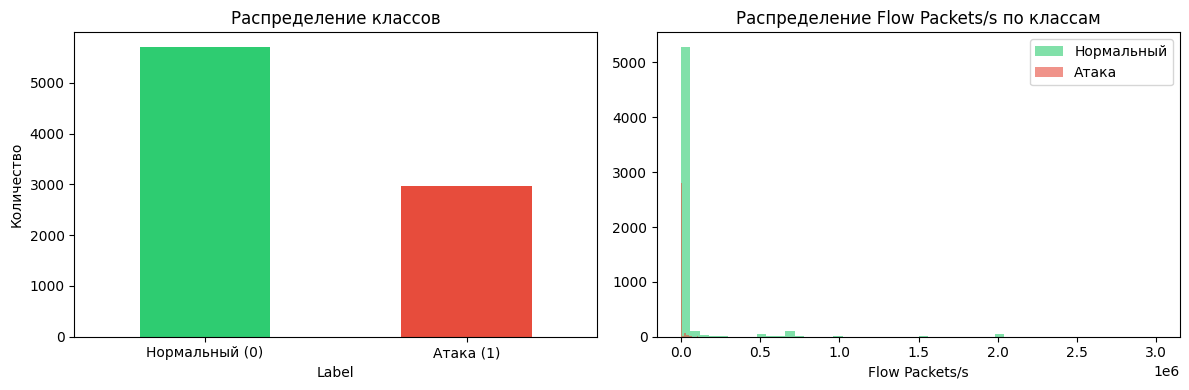

In [56]:
# Визуализация распределения классов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Баланс классов
df['Label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Распределение классов')
axes[0].set_xticklabels(['Нормальный (0)', 'Атака (1)'], rotation=0)
axes[0].set_ylabel('Количество')

# Распределение одного из ключевых признаков
for label, color, name in [(0, '#2ecc71', 'Нормальный'), (1, '#e74c3c', 'Атака')]:
    axes[1].hist(df[df['Label']==label]['Flow Packets/s'], bins=50,
                 alpha=0.6, color=color, label=name)
axes[1].set_title('Распределение Flow Packets/s по классам')
axes[1].set_xlabel('Flow Packets/s')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Предобработка данных для нейросети

Нейронные сети чувствительны к масштабу признаков. Если один признак имеет значения от 0 до 1, а другой — от 0 до 1 000 000, то сеть будет «обращать внимание» в основном на второй.

**Стандартизация (Z-score)** приводит каждый признак к единому масштабу:

$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

После стандартизации каждый признак имеет среднее ≈ 0 и стандартное отклонение ≈ 1.

> ⚠️ **Важно**: параметры стандартизации ($\mu$ и $\sigma$) вычисляются **только по обучающей выборке**, а затем применяются к валидационной и тестовой.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Разделяем признаки и метки
X = df.drop('Label', axis=1).values.astype(np.float32)
y = df['Label'].values.astype(np.float32)

print(f"Признаки: {X.shape}  (samples x features)")
print(f"Метки:    {y.shape}")

# Разделяем на обучающую (70%), валидационную (15%) и тестовую (15%) выборки
# stratify=y сохраняет пропорции классов в каждой выборке
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nОбучающая выборка:    {X_train.shape[0]} записей")
print(f"Валидационная выборка: {X_val.shape[0]} записей")
print(f"Тестовая выборка:      {X_test.shape[0]} записей")

Признаки: (8674, 38)  (samples x features)
Метки:    (8674,)

Обучающая выборка:    6071 записей
Валидационная выборка: 1301 записей
Тестовая выборка:      1302 записей


In [58]:
# Стандартизация признаков
scaler = StandardScaler()

# fit_transform — вычисляем μ и σ по обучающей выборке и применяем
X_train = scaler.fit_transform(X_train)

# transform — применяем те же μ и σ к валидационной и тестовой выборкам
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("После стандартизации (обучающая выборка):")
print(f"  Среднее:   {X_train.mean(axis=0)[:5].round(4)}")
print(f"  Стд. откл: {X_train.std(axis=0)[:5].round(4)}")

После стандартизации (обучающая выборка):
  Среднее:   [ 0. -0. -0.  0. -0.]
  Стд. откл: [1. 1. 1. 1. 1.]


In [59]:
# Преобразуем NumPy массивы в тензоры PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # (N,) -> (N,1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"Обучающие тензоры: X={X_train_t.shape}, y={y_train_t.shape}")
print(f"Валидационные:     X={X_val_t.shape}, y={y_val_t.shape}")
print(f"Тестовые:          X={X_test_t.shape}, y={y_test_t.shape}")

Обучающие тензоры: X=torch.Size([6071, 38]), y=torch.Size([6071, 1])
Валидационные:     X=torch.Size([1301, 38]), y=torch.Size([1301, 1])
Тестовые:          X=torch.Size([1302, 38]), y=torch.Size([1302, 1])


---
## 4. Нейронная сеть и инициализация весов в PyTorch

### 4.1 Архитектура сети

![pytorch](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-training-loop-annotated.png)

Для задачи бинарной классификации сетевого трафика мы построим **полносвязную нейронную сеть (MLP — Multi-Layer Perceptron)**:

```
Входной слой (38 признаков)
       ↓
Скрытый слой 1 (128 нейронов) + ReLU + BatchNorm
       ↓
Скрытый слой 2 (64 нейрона)  + ReLU + BatchNorm
       ↓
Скрытый слой 3 (32 нейрона)  + ReLU + BatchNorm
       ↓
Выходной слой (1 нейрон) + Sigmoid
```

- **ReLU** (Rectified Linear Unit) — функция активации: $f(x) = \max(0, x)$
- **BatchNorm** — нормализует выходы слоя, ускоряет обучение
- **Sigmoid** — преобразует выход в вероятность: $\sigma(x) = \frac{1}{1 + e^{-x}}$

### 4.2 Инициализация весов

Правильная инициализация весов критически важна:

| Метод | Формула | Когда использовать |
|-------|---------|--------------------|
| **Xavier (Glorot)** | $W \sim U(-\sqrt{6/(n_{in}+n_{out})}, \sqrt{6/(n_{in}+n_{out})})$ | Sigmoid, Tanh |
| **Kaiming (He)** | $W \sim N(0, \sqrt{2/n_{in}})$ | ReLU, LeakyReLU |
| **Нули** | $W = 0$ | ❌ Никогда для весов! Только для bias |

Мы используем **Kaiming**, поскольку наши активации — ReLU.

In [60]:
import torch.nn as nn

class NetworkTrafficClassifier(nn.Module):
    """
    Нейросетевой классификатор сетевого трафика.
    Полносвязная сеть с 3 скрытыми слоями, BatchNorm и ReLU.
    """

    def __init__(self, input_dim, hidden_dims=[128, 64, 32]):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Строим скрытые слои
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),   # полносвязный слой
                nn.BatchNorm1d(h_dim),         # батч-нормализация
                nn.ReLU(),                     # функция активации
            ])
            prev_dim = h_dim

        # Выходной слой: 1 нейрон с сигмоидой для бинарной классификации
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        # nn.Sequential объединяет слои в единый конвейер
        self.network = nn.Sequential(*layers)

        # Инициализируем веса
        self._init_weights()

    def _init_weights(self):
        """Инициализация весов методом Kaiming (He) для ReLU."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                # Kaiming-инициализация для весов
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                # Нулевая инициализация для смещений (bias)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        """Прямой проход: данные проходят через все слои последовательно."""
        return self.network(x)


# Создаём модель
input_dim = X_train_t.shape[1]  # количество признаков
model = NetworkTrafficClassifier(input_dim)

print(model)
print(f"\nКоличество параметров: {sum(p.numel() for p in model.parameters()):,}")

NetworkTrafficClassifier(
  (network): Sequential(
    (0): Linear(in_features=38, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Количество параметров: 15,809


In [61]:
# Посмотрим на инициализированные веса первого слоя
first_linear = list(model.modules())[1]  # Первый nn.Linear
if hasattr(first_linear, 'weight'):
    weights = first_linear.weight.data
    print(f"Форма весов первого слоя: {weights.shape}")
    print(f"Среднее: {weights.mean():.4f}")
    print(f"Стд. отклонение: {weights.std():.4f}")

    # Визуализация распределения весов
    plt.figure(figsize=(8, 3))
    plt.hist(weights.flatten().numpy(), bins=50, color='steelblue', edgecolor='white')
    plt.title('Распределение весов первого слоя (Kaiming init)')
    plt.xlabel('Значение веса')
    plt.ylabel('Частота')
    plt.show()

---
## 5. Обучение модели: пакетный градиентный спуск, метрики, мониторинг

### 5.1 Функция потерь

Для бинарной классификации используется **Binary Cross-Entropy (BCE)**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Она штрафует модель тем сильнее, чем увереннее модель ошибается.

### 5.2 Пакетный (Mini-batch) градиентный спуск

Вместо подачи **всех** данных за раз (batch GD) или **по одному** примеру (SGD), мы используем **мини-батчи** — группы из нескольких сотен примеров:

| Метод | Размер пакета | Плюсы | Минусы |
|-------|---------------|-------|--------|
| Batch GD | Весь датасет | Стабильная сходимость | Медленный, много памяти |
| SGD | 1 пример | Быстрый, мало памяти | Шумные градиенты |
| **Mini-batch** | 32-512 | Баланс скорости и стабильности | Нужно подбирать размер |

### 5.3 Метрики

Для задачи обнаружения атак **accuracy недостаточно**. Нам важно:

- **Precision** (точность) — какая доля найденных «атак» действительно атаки?
- **Recall** (полнота) — какую долю реальных атак мы нашли?
- **F1-score** — гармоническое среднее Precision и Recall

In [62]:
from torch.utils.data import TensorDataset, DataLoader

# Предполагаем, что у вас уже есть тензоры:
# X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t

BATCH_SIZE = 256

# 1. Создаём DataLoader'ы
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Батчей в обучающей выборке: {len(train_loader)}")
print(f"Размер батча: {BATCH_SIZE}")

# Проверяем один батч
sample_X, sample_y = next(iter(train_loader))
print(f"Форма батча: X={sample_X.shape}, y={sample_y.shape}")

# 2. Определяем модель (пример – StudentClassifier)
# Предполагается, что input_dim = X_train_t.shape[1]
input_dim = X_train_t.shape[1]
student_model = StudentClassifier(input_dim=input_dim, dropout_rate=0.25)

# 3. Оптимизатор и функция потерь
student_optimizer = torch.optim.Adam(student_model.parameters(), lr=0.001, weight_decay=1e-4)
student_criterion = nn.BCELoss()

# 4. Цикл обучения (пример на 1 эпоху, без ранней остановки)
student_model.train()
train_losses = []
all_train_preds = []
all_train_labels = []

for X_batch, y_batch in train_loader:
    # Прямой проход
    predictions = student_model(X_batch)
    loss = student_criterion(predictions, y_batch)

    # Обратный проход
    student_optimizer.zero_grad()
    loss.backward()
    student_optimizer.step()

    # Сохраняем метрики
    train_losses.append(loss.item())
    all_train_preds.append(predictions.detach())
    all_train_labels.append(y_batch)

print("✅ Обучение завершено (одна эпоха)")

Батчей в обучающей выборке: 24
Размер батча: 256
Форма батча: X=torch.Size([256, 38]), y=torch.Size([256, 1])
✅ Обучение завершено (одна эпоха)


In [63]:
# === Функции для вычисления метрик ===

def compute_metrics(y_true, y_pred_prob, threshold=0.5):
    """
    Вычисляет метрики бинарной классификации.

    Args:
        y_true: истинные метки (0 или 1)
        y_pred_prob: предсказанные вероятности (0..1)
        threshold: порог для бинаризации

    Returns:
        словарь с метриками
    """
    y_pred = (y_pred_prob >= threshold).float()

    # True Positives, False Positives, True Negatives, False Negatives
    tp = ((y_pred == 1) & (y_true == 1)).sum().float()
    model_sgd.train()  # включаем режим обучения (BatchNorm, Dropout работают)
    train_losses = []
    all_train_preds = []
    all_train_labels = []

    for X_batch, y_batch in train_loader:
        # 1. Прямой проход (forward pass)
        predictions = model_sgd(X_batch)
    fp = ((y_pred == 1) & (y_true == 0)).sum().float()
    tn = ((y_pred == 0) & (y_true == 0)).sum().float()
    fn = ((y_pred == 0) & (y_true == 1)).sum().float()

    accuracy  = (tp + tn) / (tp + fp + tn + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)  # 1e-8 для избежания деления на 0
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        'accuracy':  accuracy.item(),
        'precision': precision.item(),
        'recall':    recall.item(),
        'f1':        f1.item(),
    }

In [66]:
# === Обучение с SGD — базовый вариант ===

# Пересоздаём модель с чистыми весами
model_sgd = NetworkTrafficClassifier(input_dim)

# Функция потерь — бинарная кросс-энтропия
criterion = nn.BCELoss()

# Оптимизатор — стохастический градиентный спуск
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

model_sgd.train()  # включаем режим обучения (BatchNorm, Dropout работают)
train_losses = []
all_train_preds = []
all_train_labels = []

for X_batch, y_batch in train_loader:
        # 1. Прямой проход (forward pass)
    predictions = model_sgd(X_batch)
# Словари для хранения истории обучения (мониторинг)
history_sgd = {
    'train_loss': [], 'val_loss': [],
    'train_f1': [], 'val_f1': []
}

NUM_EPOCHS = 50

print("Обучение модели с SGD...")
print(f"{'Эпоха':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train F1':>10} | {'Val F1':>10}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # === ОБУЧЕНИЕ ===
    model_sgd.train()  # включаем режим обучения (BatchNorm, Dropout работают)
    train_losses = []
    all_train_preds = []
    all_train_labels = []

    for X_batch, y_batch in train_loader:
        # 1. Прямой проход (forward pass)
        predictions = model_sgd(X_batch)
        loss = criterion(predictions, y_batch)

        # 2. Обратный проход (backward pass) — вычисление градиентов
        optimizer_sgd.zero_grad()  # обнуляем градиенты от прошлого шага
        loss.backward()            # вычисляем градиенты

        # 3. Обновление весов
        optimizer_sgd.step()

        train_losses.append(loss.item())
        all_train_preds.append(predictions.detach())
        all_train_labels.append(y_batch)

    # Метрики на обучающей выборке
    train_preds = torch.cat(all_train_preds)
    train_labels = torch.cat(all_train_labels)
    train_metrics = compute_metrics(train_labels, train_preds)

    # === ВАЛИДАЦИЯ ===
    model_sgd.eval()  # выключаем режим обучения
    val_losses = []
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():  # отключаем вычисление градиентов для экономии памяти
        for X_batch, y_batch in val_loader:
            predictions = model_sgd(X_batch)
            loss = criterion(predictions, y_batch)
            val_losses.append(loss.item())
            all_val_preds.append(predictions)
            all_val_labels.append(y_batch)

    val_preds = torch.cat(all_val_preds)
    val_labels = torch.cat(all_val_labels)
    val_metrics = compute_metrics(val_labels, val_preds)

    # Сохраняем историю
    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    history_sgd['train_loss'].append(avg_train_loss)
    history_sgd['val_loss'].append(avg_val_loss)
    history_sgd['train_f1'].append(train_metrics['f1'])
    history_sgd['val_f1'].append(val_metrics['f1'])

    # Выводим каждую 5-ю эпоху
    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1:>6} | {avg_train_loss:>10.4f} | {avg_val_loss:>10.4f} | "
              f"{train_metrics['f1']:>10.4f} | {val_metrics['f1']:>10.4f}")

print("\n✅ Обучение завершено!")

Обучение модели с SGD...
 Эпоха | Train Loss |   Val Loss |   Train F1 |     Val F1
------------------------------------------------------------
     5 |     0.2282 |     0.2326 |     0.8583 |     0.8575
    10 |     0.1929 |     0.2142 |     0.8799 |     0.8682
    15 |     0.1752 |     0.1956 |     0.8903 |     0.8758
    20 |     0.1641 |     0.1753 |     0.8955 |     0.8806
    25 |     0.1621 |     0.1504 |     0.8959 |     0.8814
    30 |     0.1587 |     0.1426 |     0.8962 |     0.8814
    35 |     0.1493 |     0.1509 |     0.8965 |     0.8824
    40 |     0.1463 |     0.1864 |     0.8966 |     0.8797
    45 |     0.1465 |     0.1674 |     0.9010 |     0.8770
    50 |     0.1368 |     0.1633 |     0.9028 |     0.8794

✅ Обучение завершено!


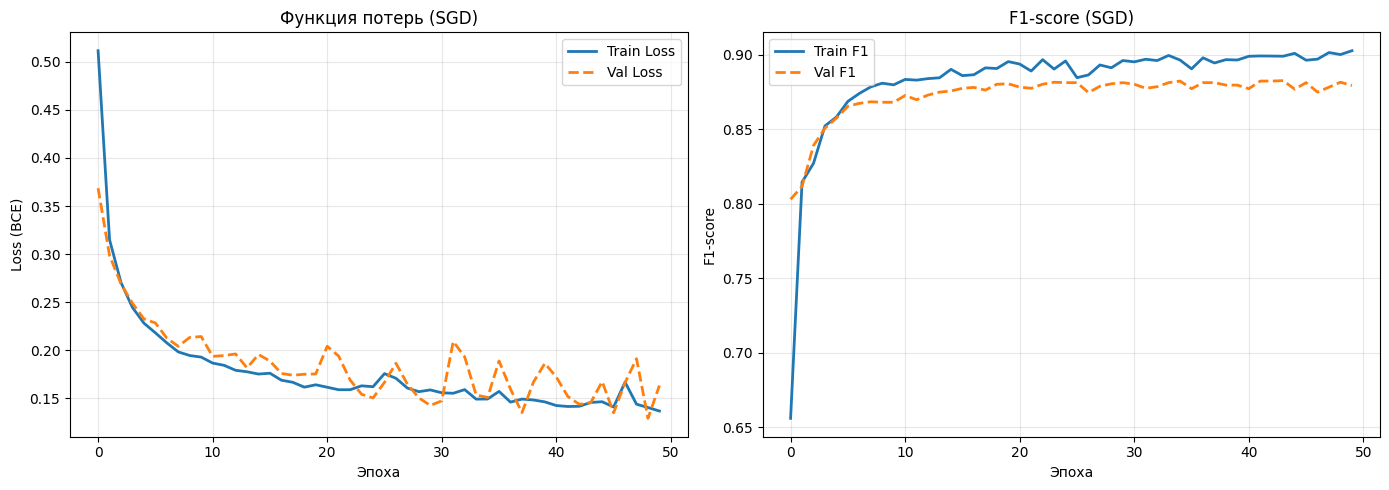

In [67]:
# === Визуализация процесса обучения (мониторинг) ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График потерь
axes[0].plot(history_sgd['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_sgd['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Функция потерь (SGD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График F1-score
axes[1].plot(history_sgd['train_f1'], label='Train F1', linewidth=2)
axes[1].plot(history_sgd['val_f1'], label='Val F1', linewidth=2, linestyle='--')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score (SGD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Если val_loss растёт при падающем train_loss — это признак переобучения!

---
## 6. Оптимизатор Adam

### 6.1 Зачем нужен Adam?

SGD с фиксированной скоростью обучения (learning rate) имеет недостатки:
- Слишком большой lr → обучение расходится
- Слишком маленький lr → обучение застревает
- Разные параметры могут требовать разной скорости

**Adam (Adaptive Moment Estimation)** решает эти проблемы, адаптируя скорость обучения **для каждого параметра индивидуально**, используя:

1. **Первый момент** $m_t$ — экспоненциальное скользящее среднее градиентов (аналог momentum)
2. **Второй момент** $v_t$ — экспоненциальное скользящее среднее квадратов градиентов

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Типичные гиперпараметры: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$, $\eta = 0.001$.

### 6.2 Сравнение SGD и Adam

In [ ]:
# === Обучение с Adam ===

model_adam = NetworkTrafficClassifier(input_dim)
criterion = nn.BCELoss()

# Adam с параметрами по умолчанию — обычно хороший выбор
optimizer_adam = torch.optim.Adam(
    model_adam.parameters(),
    lr=0.001,          # начальная скорость обучения
    betas=(0.9, 0.999), # коэффициенты для моментов
    weight_decay=0      # пока без L2-регуляризации
)

history_adam = {
    'train_loss': [], 'val_loss': [],
    'train_f1': [], 'val_f1': []
}

print("Обучение модели с Adam...")
print(f"{'Эпоха':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train F1':>10} | {'Val F1':>10}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # Обучение
    model_adam.train()
    train_losses = []
    all_preds, all_labels = [], []

    for X_batch, y_batch in train_loader:
        predictions = model_adam(X_batch)
        loss = criterion(predictions, y_batch)

        optimizer_adam.zero_grad()
        loss.backward()
        optimizer_adam.step()

        train_losses.append(loss.item())
        all_preds.append(predictions.detach())
        all_labels.append(y_batch)

    train_metrics = compute_metrics(torch.cat(all_labels), torch.cat(all_preds))

    # Валидация
    model_adam.eval()
    val_losses = []
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            predictions = model_adam(X_batch)
            loss = criterion(predictions, y_batch)
            val_losses.append(loss.item())
            all_preds.append(predictions)
            all_labels.append(y_batch)

    val_metrics = compute_metrics(torch.cat(all_labels), torch.cat(all_preds))

    # Сохраняем историю
    avg_tl = np.mean(train_losses)
    avg_vl = np.mean(val_losses)
    history_adam['train_loss'].append(avg_tl)
    history_adam['val_loss'].append(avg_vl)
    history_adam['train_f1'].append(train_metrics['f1'])
    history_adam['val_f1'].append(val_metrics['f1'])

    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1:>6} | {avg_tl:>10.4f} | {avg_vl:>10.4f} | "
              f"{train_metrics['f1']:>10.4f} | {val_metrics['f1']:>10.4f}")

print("\n✅ Обучение завершено!")

In [ ]:
# === Сравнение SGD и Adam ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_sgd['val_loss'], label='SGD (val)', linewidth=2, color='#e74c3c')
axes[0].plot(history_adam['val_loss'], label='Adam (val)', linewidth=2, color='#3498db')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Сравнение Val Loss: SGD vs Adam')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1
axes[1].plot(history_sgd['val_f1'], label='SGD (val)', linewidth=2, color='#e74c3c')
axes[1].plot(history_adam['val_f1'], label='Adam (val)', linewidth=2, color='#3498db')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Validation F1-score')
axes[1].set_title('Сравнение Val F1: SGD vs Adam')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Обратите внимание: Adam обычно сходится быстрее, особенно в первые эпохи.")

---
## 7. Борьба с переобучением: полный пример с регуляризацией, Dropout и ранней остановкой

**Переобучение (Overfitting)** — ситуация, когда модель отлично работает на обучающих данных, но плохо обобщает на новые. Это главная проблема при обучении нейросетей.

### Признаки переобучения:
- `train_loss` продолжает падать, а `val_loss` начинает расти
- Большой разрыв между `train_f1` и `val_f1`

### Методы борьбы:

| Метод | Описание | Как работает |
|-------|----------|-------------|
| **L2-регуляризация** | Штраф за большие веса | Добавляет $\lambda\|\mathbf{w}\|^2$ к функции потерь |
| **Dropout** | Случайное отключение нейронов | На каждом шаге обучения случайные нейроны «выключаются» |
| **Ранняя остановка** | Остановка при ухудшении val_loss | Сохраняет лучшую модель, останавливает при стагнации |

### 7.1 Обновлённая модель с Dropout

Ниже мы соберём всё вместе: модель с Dropout, Adam с L2-регуляризацией (weight_decay), ранняя остановка и полный цикл обучения с оценкой на тестовой выборке.

In [ ]:
class RobustTrafficClassifier(nn.Module):
    """
    Улучшенный классификатор с Dropout для борьбы с переобучением.

    Dropout случайным образом «выключает» часть нейронов во время обучения,
    заставляя сеть не полагаться на отдельные нейроны. Это похоже на
    ансамблирование — мы тренируем множество «подсетей» одновременно.

    При инференсе (model.eval()) Dropout отключается, а выходы
    масштабируются автоматически.
    """

    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate),  # случайно отключаем dropout_rate% нейронов
            ])
            prev_dim = h_dim

        # Выходной слой — без Dropout и BatchNorm
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        """Kaiming-инициализация для слоёв с ReLU."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.network(x)


print("Архитектура модели с Dropout:")
print(RobustTrafficClassifier(input_dim))

In [ ]:
class EarlyStopping:
    """
    Ранняя остановка: прекращает обучение, если val_loss не улучшается.

    Принцип работы:
    - Отслеживаем лучшее значение val_loss
    - Если val_loss не улучшается patience эпох подряд — останавливаем
    - Сохраняем веса лучшей модели и восстанавливаем их в конце

    Args:
        patience: сколько эпох ждать без улучшения
        min_delta: минимальное улучшение, которое считается прогрессом
    """

    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_model_state = None
        self.should_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            # Первая эпоха — сохраняем как лучшую
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
        elif val_loss < self.best_loss - self.min_delta:
            # Есть улучшение — сбрасываем счётчик
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
            self.counter = 0
        else:
            # Нет улучшения — увеличиваем счётчик
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore_best_model(self, model):
        """Восстанавливает веса лучшей модели."""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)

In [ ]:
# === ПОЛНЫЙ ЦИКЛ ОБУЧЕНИЯ С ВСЕМИ ТЕХНИКАМИ ===

# Гиперпараметры
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 1e-4    # L2-регуляризация (лямбда)
DROPOUT_RATE  = 0.3     # вероятность отключения нейрона
PATIENCE      = 15      # терпение для ранней остановки
MAX_EPOCHS    = 200     # максимум эпох (ранняя остановка может прервать раньше)

# Создаём модель с Dropout
model_final = RobustTrafficClassifier(
    input_dim=input_dim,
    hidden_dims=[128, 64, 32],
    dropout_rate=DROPOUT_RATE
)

# Adam с L2-регуляризацией (weight_decay)
# weight_decay добавляет к градиенту член λ·w, что эквивалентно L2-штрафу
optimizer = torch.optim.Adam(
    model_final.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Планировщик скорости обучения — уменьшает lr при стагнации
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # следим за минимизацией val_loss
    factor=0.5,       # уменьшаем lr в 2 раза
    patience=5,       # ждём 5 эпох без улучшения
)

criterion = nn.BCELoss()
early_stopping = EarlyStopping(patience=PATIENCE)

# История для мониторинга
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [], 'val_recall': [],
    'lr': []
}

print("=" * 80)
print("    ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print(f"    Dropout={DROPOUT_RATE}, L2={WEIGHT_DECAY}, lr={LEARNING_RATE}, patience={PATIENCE}")
print("=" * 80)
print(f"{'Эпоха':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
      f"{'Train F1':>9} | {'Val F1':>9} | {'LR':>10}")
print("-" * 72)

for epoch in range(MAX_EPOCHS):
    # === ОБУЧЕНИЕ ===
    model_final.train()
    train_losses = []
    all_preds, all_labels = [], []

    for X_batch, y_batch in train_loader:
        predictions = model_final(X_batch)
        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        all_preds.append(predictions.detach())
        all_labels.append(y_batch)

    train_metrics = compute_metrics(torch.cat(all_labels), torch.cat(all_preds))

    # === ВАЛИДАЦИЯ ===
    model_final.eval()
    val_losses = []
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            predictions = model_final(X_batch)
            loss = criterion(predictions, y_batch)
            val_losses.append(loss.item())
            all_preds.append(predictions)
            all_labels.append(y_batch)

    val_metrics = compute_metrics(torch.cat(all_labels), torch.cat(all_preds))

    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    current_lr = optimizer.param_groups[0]['lr']

    verbose=True
    # Сохраняем полную историю
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['train_f1'].append(train_metrics['f1'])
    history['val_f1'].append(val_metrics['f1'])
    history['train_precision'].append(train_metrics['precision'])
    history['val_precision'].append(val_metrics['precision'])
    history['train_recall'].append(train_metrics['recall'])
    history['val_recall'].append(val_metrics['recall'])
    history['lr'].append(current_lr)

    # Обновляем планировщик lr
    scheduler.step(avg_val_loss)

    # Проверяем раннюю остановку
    early_stopping(avg_val_loss, model_final)

    # Вывод каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:>6} | {avg_train_loss:>10.4f} | {avg_val_loss:>10.4f} | "
              f"{train_metrics['f1']:>9.4f} | {val_metrics['f1']:>9.4f} | {current_lr:>10.6f}")

    if early_stopping.should_stop:
        print(f"\n⏹ Ранняя остановка на эпохе {epoch+1}! Val Loss не улучшался {PATIENCE} эпох.")
        break

# Восстанавливаем лучшую модель
early_stopping.restore_best_model(model_final)
print(f"\n✅ Восстановлены веса лучшей модели (val_loss = {early_stopping.best_loss:.4f})")

In [ ]:
# === ПОДРОБНАЯ ВИЗУАЛИЗАЦИЯ ОБУЧЕНИЯ ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[0, 0].set_title('Функция потерь (BCE Loss)', fontsize=13)
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Validation', linewidth=2, linestyle='--')
axes[0, 1].set_title('Accuracy', fontsize=13)
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision и Recall
axes[1, 0].plot(history['val_precision'], label='Val Precision', linewidth=2, color='#2ecc71')
axes[1, 0].plot(history['val_recall'], label='Val Recall', linewidth=2, color='#e74c3c')
axes[1, 0].plot(history['val_f1'], label='Val F1', linewidth=2, color='#3498db', linestyle='--')
axes[1, 0].set_title('Precision, Recall, F1 (валидация)', fontsize=13)
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Learning Rate
axes[1, 1].plot(history['lr'], linewidth=2, color='#9b59b6')
axes[1, 1].set_title('Скорость обучения (Learning Rate)', fontsize=13)
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('LR')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Мониторинг обучения финальной модели', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Оценка на тестовой выборке

Тестовая выборка используется **только один раз** — для финальной оценки модели. Она имитирует реальные данные, которые модель никогда не видела.

In [ ]:
# === ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ ===

model_final.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model_final(X_batch)
        all_preds.append(predictions)
        all_labels.append(y_batch)

test_preds = torch.cat(all_preds)
test_labels = torch.cat(all_labels)
test_metrics = compute_metrics(test_labels, test_preds)

print("=" * 50)
print("   РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 50)
print(f"   Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"   Precision: {test_metrics['precision']:.4f}")
print(f"   Recall:    {test_metrics['recall']:.4f}")
print(f"   F1-score:  {test_metrics['f1']:.4f}")
print("=" * 50)

In [ ]:
# === Матрица ошибок (Confusion Matrix) ===

test_pred_binary = (test_preds >= 0.5).float()

tp = ((test_pred_binary == 1) & (test_labels == 1)).sum().item()
fp = ((test_pred_binary == 1) & (test_labels == 0)).sum().item()
tn = ((test_pred_binary == 0) & (test_labels == 0)).sum().item()
fn = ((test_pred_binary == 0) & (test_labels == 1)).sum().item()

confusion = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Предсказано:\nНормальный', 'Предсказано:\nАтака'],
            yticklabels=['На самом деле:\nНормальный', 'На самом деле:\nАтака'])
ax.set_title('Матрица ошибок (Confusion Matrix)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives  (верно нормальный): {tn}")
print(f"False Positives (ложная тревога):    {fp}")
print(f"False Negatives (пропуск атаки):     {fn}")
print(f"True Positives  (верно атака):       {tp}")

In [ ]:
# === Распределение предсказанных вероятностей ===

fig, ax = plt.subplots(figsize=(10, 4))

# Вероятности для каждого класса
normal_probs = test_preds[test_labels == 0].numpy().flatten()
attack_probs = test_preds[test_labels == 1].numpy().flatten()

ax.hist(normal_probs, bins=50, alpha=0.6, color='#2ecc71', label='Нормальный трафик')
ax.hist(attack_probs, bins=50, alpha=0.6, color='#e74c3c', label='Атака')
ax.axvline(x=0.5, color='black', linestyle='--', label='Порог = 0.5')
ax.set_xlabel('Предсказанная вероятность атаки')
ax.set_ylabel('Количество')
ax.set_title('Распределение предсказанных вероятностей по классам')
ax.legend()
plt.tight_layout()
plt.show()

print("Чем лучше разделены распределения — тем увереннее модель в своих предсказаниях.")

---
## Итоги

В этом ноутбуке мы прошли полный пайплайн обнаружения сетевых атак:

1. **Извлечение признаков** из сетевого трафика с помощью NFStream — pcap-файлы преобразуются в таблицу признаков потоков
2. **Основы PyTorch** — тензоры, операции, автоградиент — базовые инструменты для глубокого обучения
3. **Предобработка** — стандартизация, разделение на train/val/test, конвертация в тензоры
4. **Архитектура нейросети** — MLP с BatchNorm, правильная инициализация весов (Kaiming)
5. **Обучение** — mini-batch gradient descent, мониторинг loss и метрик на каждой эпохе
6. **Adam** — адаптивный оптимизатор, сходится быстрее SGD
7. **Борьба с переобучением** — Dropout, L2-регуляризация (weight_decay), ранняя остановка, планировщик lr

### Что можно улучшить дальше?

- Использовать реальные датасеты (CICIDS2017, NSL-KDD)
- Попробовать **мультиклассовую** классификацию (разные типы атак)
- Применить **аугментацию данных** для увеличения выборки
- Использовать **Cross-Validation** для более надёжной оценки
- Сравнить с классическими методами (Random Forest, XGBoost)
- Добавить **интерпретируемость** (SHAP, Feature Importance)

---
## 📝 Задание для самостоятельной работы

Реализуйте улучшенную версию классификатора, следуя инструкциям в `TODO`.

**Задача:** Построить модель с 4 скрытыми слоями `[256, 128, 64, 32]`, обучить её с использованием всех изученных техник и добиться **F1-score ≥ 0.75** на тестовой выборке.

> ⚠️ Не меняйте сигнатуры функций и имена переменных — автоматические тесты проверяют именно их.

In [70]:
# ============================================================
# ЗАДАНИЕ: Реализуйте улучшенный классификатор
# ============================================================

import torch
import torch.nn as nn

class StudentClassifier(nn.Module):
    """
    TODO 1: Реализуйте нейросеть со следующей архитектурой:
      - 4 скрытых слоя с размерностями [256, 128, 64, 32]
      - Каждый скрытый слой: Linear → BatchNorm1d → ReLU → Dropout
      - Выходной слой: Linear(32, 1) → Sigmoid
      - dropout_rate передаётся как параметр конструктора

    TODO 2: Реализуйте Kaiming-инициализацию весов (как в примере выше).
    """

    def __init__(self, input_dim, dropout_rate=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )  # TODO: замените None на nn.Sequential(...)
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                if module.bias is not None:
                  #module.bias.data.zero_()
                  nn.init.zeros_(module.bias)
        pass
        # ---

    def forward(self, x):
        return self.network(x)


# TODO 3: Создайте модель, оптимизатор и функцию потерь
# - модель: StudentClassifier с dropout_rate=0.25
# - оптимизатор: Adam, lr=0.001, weight_decay=1e-4
# - функция потерь: BCELoss

student_model = StudentClassifier(input_dim=input_dim, dropout_rate=0.25)      # TODO: создайте экземпляр StudentClassifier
student_optimizer = torch.optim.Adam(
    student_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)   # TODO: создайте оптимизатор Adam
student_criterion = nn.BCELoss()   # TODO: создайте функцию потерь


# TODO 4: Обучите модель на 80 эпохах с ранней остановкой (patience=15).
#          Сохраняйте лучшую модель по val_loss.
#          В конце обучения восстановите лучшие веса.
#
# Подсказки:
#   - Используйте train_loader и val_loader, определённые ранее
#   - Не забудьте model.train() / model.eval()
#   - Используйте torch.no_grad() при валидации

student_train_losses = []  # сюда записывайте средний train_loss каждой эпохи
student_val_losses = []    # сюда записывайте средний val_loss каждой эпохи
best_val_loss = float('inf')
best_state_dict = None
patience_counter = 0
PATIENCE = 15
MAX_EPOCHS = 80

for epoch in range(MAX_EPOCHS):
    # === ОБУЧЕНИЕ ===
    student_model.train()
    train_losses = []
    all_preds, all_labels = [], []

    for X_batch, y_batch in train_loader:
        predictions = student_model(X_batch)
        loss = student_criterion(predictions, y_batch)

        student_optimizer.zero_grad()
        loss.backward()
        student_optimizer.step()

        train_losses.append(loss.item())
        all_preds.append(predictions.detach())
        all_labels.append(y_batch)

    # === ВАЛИДАЦИЯ ===
    student_model.eval()
    val_losses = []
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            predictions = student_model(X_batch)
            loss = student_criterion(predictions, y_batch)
            val_losses.append(loss.item())
            all_preds.append(predictions)
            all_labels.append(y_batch)

    avg_train_loss = np.mean(train_losses)
    student_train_losses.append(avg_train_loss)
    avg_val_loss = np.mean(val_losses)
    student_val_losses.append(avg_val_loss)

    current_lr = student_optimizer.param_groups[0]['lr']

    #verbose=True

    # Обновляем планировщик lr
    #scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state_dict = student_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Ранняя остановка на эпохе {epoch+1}")
        break

# Восстанавливаем лучшую модель
if best_state_dict is not None:
    student_model.load_state_dict(best_state_dict)

print("✅ Обучение завершено!")

✅ Обучение завершено!


Тесты для проверки решения задания

In [71]:
# ============================================================
# 🧪 АВТОМАТИЧЕСКАЯ ПРОВЕРКА РЕШЕНИЯ
# Не изменяйте эту ячейку!
# ============================================================

import traceback

_passed = 0
_failed = 0

def _check(name, condition, hint=""):
    global _passed, _failed
    if condition:
        print(f"  ✅ {name}")
        _passed += 1
    else:
        msg = f"  ❌ {name}"
        if hint:
            msg += f"  ← {hint}"
        print(msg)
        _failed += 1

print("=" * 60)
print("  ПРОВЕРКА РЕШЕНИЯ")
print("=" * 60)

# --- Тест 1: Модель создана ---
print("\n📦 Тест 1: Создание модели")
_check("student_model — экземпляр nn.Module",
       isinstance(student_model, nn.Module),
       "student_model должен быть экземпляром nn.Module")

_check("student_model — экземпляр StudentClassifier",
       type(student_model).__name__ == "StudentClassifier",
       "Используйте StudentClassifier")

# --- Тест 2: Архитектура ---
print("\n🏗️ Тест 2: Архитектура сети")
linear_layers = [m for m in student_model.modules() if isinstance(m, nn.Linear)]
_check(f"Количество Linear слоёв = 5 (4 скрытых + 1 выходной), найдено: {len(linear_layers)}",
       len(linear_layers) == 5,
       "Нужно 4 скрытых слоя [256,128,64,32] + 1 выходной")

if len(linear_layers) == 5:
    expected_out = [256, 128, 64, 32, 1]
    actual_out = [l.out_features for l in linear_layers]
    _check(f"Размерности слоёв: {actual_out} == {expected_out}",
           actual_out == expected_out,
           f"Ожидается {expected_out}")

    _check(f"Входная размерность первого слоя = {input_dim}",
           linear_layers[0].in_features == input_dim,
           f"Первый слой должен принимать {input_dim} признаков")

bn_layers = [m for m in student_model.modules() if isinstance(m, nn.BatchNorm1d)]
_check(f"Количество BatchNorm слоёв = 4, найдено: {len(bn_layers)}",
       len(bn_layers) == 4,
       "BatchNorm нужен после каждого скрытого Linear")

dropout_layers = [m for m in student_model.modules() if isinstance(m, nn.Dropout)]
_check(f"Количество Dropout слоёв = 4, найдено: {len(dropout_layers)}",
       len(dropout_layers) == 4,
       "Dropout нужен в каждом скрытом блоке")

if len(dropout_layers) > 0:
    _check(f"Dropout rate = 0.25, найдено: {dropout_layers[0].p}",
           abs(dropout_layers[0].p - 0.25) < 1e-6,
           "dropout_rate должен быть 0.25")

has_sigmoid = any(isinstance(m, nn.Sigmoid) for m in student_model.modules())
_check("Sigmoid на выходе",
       has_sigmoid,
       "Последний слой должен содержать Sigmoid")

# --- Тест 3: Инициализация весов ---
print("\n⚖️ Тест 3: Инициализация весов")
first_linear = linear_layers[0] if linear_layers else None
if first_linear is not None:
    w = first_linear.weight.data
    _check(f"Среднее весов первого слоя ≈ 0 (|mean|={abs(w.mean().item()):.4f} < 0.1)",
           abs(w.mean().item()) < 0.1,
           "Kaiming init даёт среднее ≈ 0")

    _check(f"Стд. откл. весов > 0.01 (std={w.std().item():.4f})",
           w.std().item() > 0.01,
           "Веса не должны быть нулевыми")

    if first_linear.bias is not None:
        b = first_linear.bias.data
        _check(f"Bias первого слоя = 0 (sum={b.sum().item():.6f})",
               abs(b.sum().item()) < 1e-6,
               "Bias должен быть инициализирован нулями")

# --- Тест 4: Оптимизатор и loss ---
print("\n🔧 Тест 4: Оптимизатор и функция потерь")
_check("Оптимизатор — Adam",
       type(student_optimizer).__name__ == "Adam",
       "Используйте torch.optim.Adam")

if hasattr(student_optimizer, 'param_groups') and len(student_optimizer.param_groups) > 0:
    pg = student_optimizer.param_groups[0]
    _check(f"Learning rate = 0.001, найдено: {pg.get('initial_lr', pg.get('lr', None))}",
           abs(pg['lr'] - 0.001) < 1e-6 or abs(pg.get('initial_lr', pg['lr']) - 0.001) < 1e-6,
           "lr должен быть 0.001")

    _check(f"Weight decay = 1e-4, найдено: {pg.get('weight_decay', None)}",
           abs(pg.get('weight_decay', 0) - 1e-4) < 1e-7,
           "weight_decay должен быть 1e-4")

_check("Функция потерь — BCELoss",
       type(student_criterion).__name__ == "BCELoss",
       "Используйте nn.BCELoss()")

# --- Тест 5: Обучение прошло ---
print("\n📈 Тест 5: Процесс обучения")
_check(f"Записаны train losses ({len(student_train_losses)} эпох)",
       len(student_train_losses) > 0,
       "student_train_losses не должен быть пустым")

_check(f"Записаны val losses ({len(student_val_losses)} эпох)",
       len(student_val_losses) > 0,
       "student_val_losses не должен быть пустым")

if len(student_train_losses) > 1:
    _check("Loss уменьшается (первый > последний)",
           student_train_losses[0] > student_train_losses[-1],
           "Модель должна обучаться — loss должен падать")

if len(student_val_losses) > 0:
    # Проверяем что ранняя остановка могла сработать (обучение < 80 эпох)
    # или прошло все 80
    n_epochs = len(student_train_losses)
    _check(f"Количество эпох: {n_epochs} (ранняя остановка или 80)",
           1 <= n_epochs <= 80,
           "Должно быть от 1 до 80 эпох")

# --- Тест 6: Качество модели ---
print("\n🎯 Тест 6: Качество на тестовой выборке")
try:
    student_model.eval()
    all_test_preds = []
    all_test_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = student_model(X_batch)
            all_test_preds.append(preds)
            all_test_labels.append(y_batch)

    test_p = torch.cat(all_test_preds)
    test_l = torch.cat(all_test_labels)

    # Проверяем что выходы — валидные вероятности
    _check(f"Выходы в диапазоне [0, 1] (min={test_p.min():.4f}, max={test_p.max():.4f})",
           test_p.min() >= 0 and test_p.max() <= 1,
           "Sigmoid должен давать значения от 0 до 1")

    # Вычисляем метрики
    final_metrics = compute_metrics(test_l, test_p)
    f1 = final_metrics['f1']
    acc = final_metrics['accuracy']
    prec = final_metrics['precision']
    rec = final_metrics['recall']

    print(f"\n  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}\n")

    _check(f"Accuracy ≥ 0.70 ({acc:.4f})",
           acc >= 0.70,
           "Модель должна достичь accuracy ≥ 70%")

    _check(f"F1-score ≥ 0.75 ({f1:.4f})",
           f1 >= 0.75,
           "Целевая метрика — F1 ≥ 0.75")

    _check("Модель не предсказывает один класс",
           0.05 < test_p.mean().item() < 0.95,
           "Среднее предсказание должно быть между 0.05 и 0.95")

except Exception as e:
    print(f"  ❌ Ошибка при инференсе: {e}")
    traceback.print_exc()
    _failed += 3

# --- Итог ---
print("\n" + "=" * 60)
total = _passed + _failed
if _failed == 0:
    print(f"  🏆 ВСЕ ТЕСТЫ ПРОЙДЕНЫ! {_passed}/{total}")
else:
    print(f"  📊 Результат: {_passed}/{total} тестов пройдено, {_failed} не пройдено")
    print(f"  💡 Исправьте ошибки и запустите ячейку заново")
print("=" * 60)

  ПРОВЕРКА РЕШЕНИЯ

📦 Тест 1: Создание модели
  ✅ student_model — экземпляр nn.Module
  ✅ student_model — экземпляр StudentClassifier

🏗️ Тест 2: Архитектура сети
  ✅ Количество Linear слоёв = 5 (4 скрытых + 1 выходной), найдено: 5
  ✅ Размерности слоёв: [256, 128, 64, 32, 1] == [256, 128, 64, 32, 1]
  ✅ Входная размерность первого слоя = 38
  ✅ Количество BatchNorm слоёв = 4, найдено: 4
  ✅ Количество Dropout слоёв = 4, найдено: 4
  ✅ Dropout rate = 0.25, найдено: 0.25
  ✅ Sigmoid на выходе

⚖️ Тест 3: Инициализация весов
  ✅ Среднее весов первого слоя ≈ 0 (|mean|=0.0003 < 0.1)
  ✅ Стд. откл. весов > 0.01 (std=0.1837)
  ❌ Bias первого слоя = 0 (sum=-0.000207)  ← Bias должен быть инициализирован нулями

🔧 Тест 4: Оптимизатор и функция потерь
  ✅ Оптимизатор — Adam
  ✅ Learning rate = 0.001, найдено: 0.001
  ✅ Weight decay = 1e-4, найдено: 0.0001
  ✅ Функция потерь — BCELoss

📈 Тест 5: Процесс обучения
  ✅ Записаны train losses (80 эпох)
  ✅ Записаны val losses (80 эпох)
  ✅ Loss уменьш